In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, json
dir = os.getcwd()

ext = ['', '/..', '/../src/models', '/../src/nlp', '/../src/synth']
sys.path += [dir + i for i in ext]

### Import **API**

In [2]:
from api.football import *

### Import **Scene**

In [3]:
import string
alph = list(string.ascii_lowercase)

In [4]:
# Automatic

FOLDER = os.path.join('transcript_9/data')
demos = [i for i in os.listdir(FOLDER) if i.startswith('demonstration')]
demos.sort()

print('Found demos:', demos)

Found demos: ['demonstration0', 'demonstration0_Mohammed', 'demonstration1_Mohammed', 'demonstration2_Mohammed']


In [5]:
# Manual
# demos = ['demonstration0_Mohammed', 'demonstration1_Mohammed', 'demonstration2_Mohammed']
# demos = ['demonstration0']

In [6]:
import string
from scene import Scene
from api.objects.registry import REGISTRY # TODO: Rename to ObjectsAPI

map = {}

for i, d in enumerate(demos):

    map[str(i + 1)] = {}

    folder = os.path.join(FOLDER, d, 'json_segments')
    diri = [i for i in os.listdir(folder) if i.endswith('.json')]
    diri.sort()

    for j, f in enumerate(diri):
        file = os.path.join(folder, f)
        with open(file) as f:
            data = json.load(f)

        map[str(i + 1)][alph[j]] = Scene.from_dict(data['scene'], REGISTRY)

In [7]:
narrations = '\n'.join([f"Demo {j + 1}: " + ' '.join([f"({alph[idx]}) {s.language}" for idx, s in enumerate(i.values())]) for j, i in enumerate(map.values())])
print(narrations)

Demo 1: (a) As you receive the ball and the midfield er drops a little bit deeper to create an angle to receive the pass in the center,pass the [0] ball [1] to the midfield [2] er.
Demo 2: (a) Once you receive the ball and the midfielder [0] drops down deeper in order to create an angle of pass,then you should [1] pass the ball to the midfielder.� [2] [3]
Demo 3: (a) As [0] a left back,as you receive the ball from the pass from the goalie and [1] the midfielder drops down to create a better angle of pass,then you should pass the ball to the midfielder.� [2] [3]
Demo 4: (a) Once [0] this [1] midfielder and the goalie passes the ball to you and you receive the ball then as a midfielder drops down you want to pass the ball to the midfielder as they're creating an angle of pass.[ [2] BL ANK [3] _ AUD IO ]


### Define the Scene & Narration

In [8]:
map

{'1': {'a': <scene.Scene at 0x136a289d0>},
 '2': {'a': <scene.Scene at 0x136a46b10>},
 '3': {'a': <scene.Scene at 0x137ca2ed0>},
 '4': {'a': <scene.Scene at 0x137ce7390>}}

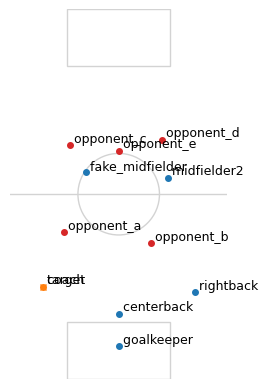

In [9]:
plotField(map['1']['a'])

In [10]:
from interpretable import Interpretable
from task import Task

tasks = Task.fromInterpretable(Interpretable(language=narrations))
print('\n\n'.join([str(t) + f'\nSources: {str(t.sources)}' for t in tasks]))

Task ID: 0
Objective (what): Pass the ball to the midfielder.
Control (how): Wait for the midfielder to drop deeper to create an angle for the pass.
Termination (until): Once the ball is successfully passed to the midfielder.
Condition (when): Upon receiving the ball from the goalie.
Sources: ['1a', '2a', '3a', '4a']


In [11]:
from action import *

act = Act()
actions = Action.fromTask(tasks, actionsAPI)
act.do(actions)

print([a.id for a in act.actions])

['Wait', 'PassTo']


In [12]:
for a in act.actions:
    a.learn(map)

{'logic': 'A AND B AND C', 'constraints': [{'id': 'A', 'api': 'HasBallPossession', 'params': {'ref': 'coach'}}, {'id': 'B', 'api': 'InZone', 'params': {'obj': 'midfielder2', 'zone': None}}, {'id': 'C', 'api': 'HasAngleOfPass', 'params': {'ref': 'midfielder2', 'radius': None}}]}
midfielder2
midfielder2


In [13]:
actions_json = act.export()
print(actions_json)

{
    "actions": [
        {
            "id": "Idle",
            "args": {
                "precondition": "lambda_precondition"
            },
            "constraints": {
                "lambda_precondition": {
                    "logical": "A AND B AND C",
                    "identifiers": [
                        "A",
                        "B",
                        "C"
                    ],
                    "args": {
                        "A": {
                            "type": "HasBallPossession",
                            "args": {
                                "ref": "coach"
                            }
                        },
                        "B": {
                            "type": "InZone",
                            "args": {
                                "obj": "midfielder2",
                                "zone": "C3"
                            }
                        },
                        "C": {
                            

### Scenic Translation

In [14]:
def construct_coach_behavior(action_json):
    function_lines = ["behavior coachBehavior():"]
    function_lines.append("    scene = simulation()")

    for action in action_json["actions"]:
        if (action == None):
            continue
        action_id = action["id"]
        args = action.get("args", {})
        
        if action_id == "MoveTo":
            dest = args.get("dest", "")
            always = args.get("always", "")
            until = args.get("until", "")
            
            if dest and always and until:
                statement = f"    do {action_id}({dest}, {always}) until {until}"
            elif dest and until:
                statement = f"    do {action_id}({dest}) until {until}"
            elif dest:
                statement = f"    do {action_id}({dest})"
            else:
                statement = f"    do {action_id}()"
        
        elif action_id == "Idle":
            precondition = args.get("precondition", "")
            if precondition:
                statement = f"    do Idle() until {precondition}"
            else:
                statement = f"    do Idle()"

        elif action_id == "PassTo":
            obj = args.get("obj", "")
            if obj:
                statement = f"    do {action_id}({obj})"
            else:
                statement = f"    do {action_id}()"

        else:
            statement = f"    do {action_id}()"
            s
        function_lines.append(statement)

    return "\n".join(function_lines)


In [15]:
import re

def synthesize_conditionals(expression):
    expression = re.sub(r'\bIF\s+(.*?)\s+THEN\s+(.*?)\s+ELSE\s+(.*?)\b', r'(\2 if \1 else \3)', expression)
    expression = expression.replace("AND", "and").replace("OR", "or") 
    return expression

def get_args(action, constraint_name):
    args = action.get("constraints", {}).get(constraint_name, {}).get("args", {})
    formatted_args = []
    for arg_name, details in args.items():
        arg_type = details["type"]
        arg_values = ", ".join([f"'{key}': {repr(value)}" for key, value in details["args"].items()])
        formatted_args.append(f"{arg_name} = {arg_type}({{{arg_values}}})")
    return "\n".join(formatted_args)

def create_constraint_definitions(action_index, example):
    action = example["actions"][action_index]
    definitions = []
    for constraint_name in action.get("constraints", {}):
        constraint_def = get_args(action, constraint_name)
        definitions.append(constraint_def)
    return "\n".join(definitions)

def create_lambda_dest(action):
    constraints = action.get("constraints", {}).get("lambda_dest", {})
    lambda_def = "def λ_dest(scene, sample):\n"
    logical_expr = constraints.get("logical", "")
    if not logical_expr:
        return lambda_def + "    return None  # No logical expression provided\n"

    logical_expr = synthesize_conditionals(logical_expr)
    for constraint_name in constraints.get("args", []):
        verify_call = f"{constraint_name}(scene, sample)"
        logical_expr = logical_expr.replace(constraint_name, verify_call)
    
    lambda_def += f"    return {logical_expr}\n"
    return lambda_def

def create_lambda_termination(action):
    constraints = action.get("constraints", {}).get("lambda_termination", {})
    lambda_def = "def λ_termination(scene, sample):\n"
    logical_expr = constraints.get("logical", "")
    
    if not logical_expr:
        return lambda_def + "    return None  # No logical expression provided\n"

    logical_expr = synthesize_conditionals(logical_expr)
    for constraint_name in constraints.get("args", []):
        verify_call = f"{constraint_name}(scene, sample)"
        logical_expr = logical_expr.replace(constraint_name, verify_call)
    
    lambda_def += f"    return {logical_expr}\n"
    return lambda_def

def create_lambda_precondition(action):
    constraints = action.get("constraints", {}).get("lambda_precondition", {})
    lambda_def = "def λ_precondition(scene, sample):\n"
    logical_expr = constraints.get("logical", "")
    
    if not logical_expr:
        return lambda_def + "    return None  # No logical expression provided\n"

    logical_expr = synthesize_conditionals(logical_expr)
    for constraint_name in constraints.get("args", []):
        verify_call = f"{constraint_name}(scene, sample)"
        logical_expr = logical_expr.replace(constraint_name, verify_call)
    
    lambda_def += f"    return {logical_expr}\n"
    return lambda_def


In [16]:
import json
actions_dict = json.loads(actions_json)
print(actions_dict)

{'actions': [{'id': 'Idle', 'args': {'precondition': 'lambda_precondition'}, 'constraints': {'lambda_precondition': {'logical': 'A AND B AND C', 'identifiers': ['A', 'B', 'C'], 'args': {'A': {'type': 'HasBallPossession', 'args': {'ref': 'coach'}}, 'B': {'type': 'InZone', 'args': {'obj': 'midfielder2', 'zone': 'C3'}}, 'C': {'type': 'HasAngleOfPass', 'args': {'ref': 'midfielder2', 'radius': {'avg': 2.7832611858380445, 'std': 0.3244048175894721}}}}}}}, {'id': 'PassTo', 'args': {'obj': 'midfielder2'}}]}


In [17]:
def generate_all_constraints_and_lambdas(example):
    for i, action in enumerate(example["actions"]):
        if (action is None):
            continue
        print(f"### Constraints and Lambda Functions for Action {i + 1}: {action['id']}")
        
        constraint_definitions = create_constraint_definitions(i, example)
        if constraint_definitions:
            print("Constraint Definitions:")
            print(constraint_definitions)
        else:
            print("No Constraint Definitions.")

        lambda_precondition_code = create_lambda_precondition(action)
        if lambda_precondition_code:
            print("\nλ_precondition Function:")
            print(lambda_precondition_code) 

        lambda_dest_code = create_lambda_dest(action)
        if lambda_dest_code:
            print("\nλ_dest Function:")
            print(lambda_dest_code)

        lambda_termination_code = create_lambda_termination(action)
        if lambda_termination_code:
            print("\nλ_termination Function:")
            print(lambda_termination_code)

        print("\n" + "=" * 40 + "\n")

generate_all_constraints_and_lambdas(actions_dict)

### Constraints and Lambda Functions for Action 1: Idle
Constraint Definitions:
A = HasBallPossession({'ref': 'coach'})
B = InZone({'obj': 'midfielder2', 'zone': 'C3'})
C = HasAngleOfPass({'ref': 'midfielder2', 'radius': {'avg': 2.7832611858380445, 'std': 0.3244048175894721}})

λ_precondition Function:
def λ_precondition(scene, sample):
    return A(scene, sample) and B(scene, sample) and C(scene, sample)


λ_dest Function:
def λ_dest(scene, sample):
    return None  # No logical expression provided


λ_termination Function:
def λ_termination(scene, sample):
    return None  # No logical expression provided



### Constraints and Lambda Functions for Action 2: PassTo
No Constraint Definitions.

λ_precondition Function:
def λ_precondition(scene, sample):
    return None  # No logical expression provided


λ_dest Function:
def λ_dest(scene, sample):
    return None  # No logical expression provided


λ_termination Function:
def λ_termination(scene, sample):
    return None  # No logical 

In [18]:
class InZone:
    def __init__(self, args):
        self.args = args

class HasAngle:
    def __init__(self, args):
        self.args = args

class IsVisible:
    def __init__(self, args):
        self.args = args

class DistanceLessThan:
    def __init__(self, args):
        self.args = args

class DistanceGreaterThan:
    def __init__(self, args):
        self.args = args


In [19]:
behavior_code = construct_coach_behavior(actions_dict)
print(behavior_code)

behavior coachBehavior():
    scene = simulation()
    do Idle() until lambda_precondition
    do PassTo(midfielder2)
